# EDA Users

### Imports y lectura de datos

In [132]:
import re


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from scipy.stats import ttest_ind
from bs4 import BeautifulSoup

np.random.seed(123)

In [133]:
#df = pd.read_xml("../../EnglishSet/Users.xml")
df = pd.read_pickle("../../EnglishSet/Users.pkl")
usuariosTrain,usuariosTest = train_test_split(df,test_size=0.3)

## Inspección General e Inicial

In [134]:
print("Dimensiones de los datos:",usuariosTrain.shape)
usuariosTrain.head(5)

Dimensiones de los datos: (278890, 12)


,Id,Reputation,CreationDate,DisplayName,LastAccessDate,WebsiteUrl,Location,AboutMe,Views,UpVotes,DownVotes,AccountId
236077,336496,1,2019-02-16T05:04:42.337,Juan Crespo,2019-02-16T05:04:42.337,None,None,None,0,0,0,15344275.0
222770,302644,1,2018-06-10T10:01:41.317,Stardestiny,2018-06-10T10:01:41.317,None,None,None,0,0,0,13747632.0
253867,369033,1,2019-12-06T14:27:18.077,p1ka2So,2023-01-30T09:47:38.690,None,None,<p>Like to play chess and bike rides.</p>\n,0,0,0,6475942.0
328166,417224,1,2021-03-11T20:56:21.120,TeenGoose,2022-10-25T17:52:16.200,NaN,"Buenos Aires, Argentina",NaN,0,0,0,20844213.0
198190,279364,1,2018-02-01T13:59:51.020,Waqar Ali Shah,2019-12-29T19:16:24.383,None,None,None,3,0,0,7615573.0


No aparecen todos los campos, faltan 2, la imagen de perfil y el emailHash. Ninguna de las dos nos iba a ser de utilidad, no pasa nada que no estén. De igual forma, el ID y AccountID en principio no nos sirven de nada ya que son identificadores que no son útiles. También se ve que los campos de fecha están mal y la estructura de los AboutMe no es un string al uso.

In [135]:
usuariosTrain.dtypes

Id                  int64
Reputation          int64
CreationDate       object
DisplayName        object
LastAccessDate     object
WebsiteUrl         object
Location           object
AboutMe            object
Views               int64
UpVotes             int64
DownVotes           int64
AccountId         float64
dtype: object

Hay que cambiar tipo de las fechas y tal vez sea buena idea ver el comportamiento de Location y tal vez separarlo en ciudad y pais. También parece no comportarse siempre de la misma manera en el AboutMe (aparece un NaN y un None). Esto puede ser casualidad y que la descripción de esa persona en concreto sea NaN.

### AboutMe

Este campo tiene una estructura rara como se dijo anteriormente, así que se verán algunos ejemplos para ver exáctamente qué forma tiene

In [136]:
muestraAboutMe = usuariosTrain.query('AboutMe.notna()')["AboutMe"].head().tolist()

for muestra in muestraAboutMe:
    print(muestra)

<p>Like to play chess and bike rides.</p>

<p><a href="https://i.stack.imgur.com/Xyzz4.png" rel="nofollow noreferrer"><img src="https://i.stack.imgur.com/Xyzz4.png" alt="enter image description here" /></a></p>

<p>Currently an indie video game developer. I also love Python 3, Django, REST, and PostgreSQL.</p>



<p><a href="https://www.gofundme.com/f/stop-stack-overflow-from-defaming-its-users" rel="nofollow noreferrer"><img src="https://i.stack.imgur.com/zktfr.png?s=328&amp;g=1" alt="Fund efforts to stop the harm to Monica Cellio" title="Additional funds appreciated"></a></p>

<p><a href="https://stackexchange.com/users/1048581/michaelb958?tab=activity"><img src="https://stackexchange.com/users/flair/1048581.png?theme=dark" alt="profile for michaelb958 on Stack Exchange, a network of free, community-driven Q&amp;A sites" title="Look, I&#39;m on Stack Exchange!"></a></p>



<p>The competition stage.
By the end of the quarter, netflix subscribers of 208 million, is still the boss of th

Este formato es HTML, como solo nos interesa realmente el texto, usaremos una herramienta llamada BeautifulSoup para poder limpiar todo lo que nos importe eliminando las tags, enlaces, imágenes etc.

### Location

La idea principal para este campo es poder parcearlo lo mejor posible, dejando tan solo el país, en caso de que tenga uno en ese campo, y si no, dejarlo como desconocido.

In [137]:
usuariosTrain[usuariosTrain["Location"].notna() & usuariosTrain["Location"].str.contains("([sS]pain|[Ee]spa[ñn]a)", na=False, regex=True)]["Location"].head(8)


/tmp/ipykernel_11806/166931191.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  usuariosTrain[usuariosTrain["Location"].notna() & usuariosTrain["Location"].str.contains("([sS]pain|[Ee]spa[ñn]a)", na=False, regex=True)]["Location"].head(8)


84115     Madrid, España
269658    Madrid, España
311853     Madrid, Spain
283283       Miño, Spain
11742      Madrid, Spain
246729     Madrid, Spain
130521             Spain
234505     Murcia, Spain
Name: Location, dtype: object

Como podemos ver, también hay que tener en cuenta que un mismo país se puede poner de diferentes formas y eso también lo tendremos que tener en cuenta al hacer los listados de paises.

In [138]:
# Diccionario de países con variantes de nombres y siglas
countries = {
    "Afghanistan": ["Afghanistan", "afghanistan", "افغانستان", "AF"],
    "Albania": ["Albania", "albania", "Shqipëri", "shqipëri", "AL"],
    "Germany": ["Germany", "germany", "Deutschland", "deutschland", "DE"],
    "Spain": ["Spain", "spain", "España", "españa", "ES"],
    "United States": ["United States", "united states", "USA", "us"],
    "United Kingdom": ["United Kingdom", "united kingdom", "UK", "uk", "Britain", "britain"],
    "Brazil": ["Brazil", "brazil", "Brasil", "brasil", "BR"],
    "France": ["France", "france", "FR"],
    "Italy": ["Italy", "italy", "Italia", "italia", "IT"],
    "Canada": ["Canada", "canada", "CA"],
    "Australia": ["Australia", "australia", "AU"],
    "Algeria": ["Algeria", "algeria", "الجزائر", "DZ"],
    "Argentina": ["Argentina", "argentina", "AR"],
    "Armenia": ["Armenia", "armenia", "Հայաստան", "AM"],
    "Australia": ["Australia", "australia", "AU"],
    "Austria": ["Austria", "austria", "Österreich", "AT"],
    "Azerbaijan": ["Azerbaijan", "azerbaijan", "Azərbaycan", "AZ"],
    "Bahamas": ["Bahamas", "bahamas", "BS"],
    "Bangladesh": ["Bangladesh", "bangladesh", "বাংলাদেশ", "BD"],
    "Barbados": ["Barbados", "barbados", "BB"],
    "Bahrain": ["Bahrain", "bahrain", "البحرين", "BH"],
    "Belgium": ["Belgium", "belgium", "BEL"],
    "Belize": ["Belize", "belize", "BZ"],
    "Benin": ["Benin", "benin", "BJ"],
    "Belarus": ["Belarus", "belarus", "Беларусь", "BY"],
    "Burma": ["Burma", "burma", "Myanmar", "MM"],
    "Bolivia": ["Bolivia", "bolivia", "BO"],
    "Bosnia and Herzegovina": ["Bosnia and Herzegovina", "bosnia and herzegovina", "Bosna i Hercegovina", "BA"],
    "Botswana": ["Botswana", "botswana", "BW"],
    "Brazil": ["Brazil", "brazil", "Brasil", "BR"],
    "Brunei": ["Brunei", "brunei", "BN"],
    "Bulgaria": ["Bulgaria", "bulgaria", "България", "BG"],
    "Burkina Faso": ["Burkina Faso", "burkina faso", "BF"],
    "Burundi": ["Burundi", "burundi", "BI"],
    "Bhutan": ["Bhutan", "bhutan", "འབྲུག", "BT"],
    "Cabo Verde": ["Cabo Verde", "cabo verde", "CV"],
    "Cambodia": ["Cambodia", "cambodia", "កម្ពុជា", "KH"],
    "Cameroon": ["Cameroon", "cameroon", "CM"],
    "Canada": ["Canada", "canada", "CA"],
    "Qatar": ["Qatar", "qatar", "QA"],
    "Chile": ["Chile", "chile", "CL"],
    "China": ["China", "china", "中国", "CN"],
    "Cyprus": ["Cyprus", "cyprus", "Κύπρος", "CY"],
    "Colombia": ["Colombia", "colombia", "CO"],
    "Comoros": ["Comoros", "comoros", "KM"],
    "North Korea": ["North Korea", "north korea", "북한", "KP"],
    "South Korea": ["South Korea", "south korea", "대한민국", "KR"],
    "Ivory Coast": ["Ivory Coast", "ivory coast", "Côte d'Ivoire", "CI"],
    "Costa Rica": ["Costa Rica", "costa rica", "CR"],
    "Croatia": ["Croatia", "croatia", "Hrvatska", "HR"],
    "Cuba": ["Cuba", "cuba", "CU"],
    "Denmark": ["Denmark", "denmark", "DK"],
    "Dominica": ["Dominica", "dominica", "DM"],
    "Ecuador": ["Ecuador", "ecuador", "EC"],
    "Egypt": ["Egypt", "egypt", "مصر", "EG"],
    "El Salvador": ["El Salvador", "el salvador", "SV"],
    "United Arab Emirates": ["United Arab Emirates", "united arab emirates", "الإمارات العربية المتحدة", "AE"],
    "Eritrea": ["Eritrea", "eritrea", "ER"],
    "Slovakia": ["Slovakia", "slovakia", "Slovensko", "SK"],
    "Slovenia": ["Slovenia", "slovenia", "Slovenija", "SI"],
    "Estonia": ["Estonia", "estonia", "EE"],
    "Ethiopia": ["Ethiopia", "ethiopia", "ኢትዮጵያ", "ET"],
    "Philippines": ["Philippines", "philippines", "フィリピン", "PH"],
    "Finland": ["Finland", "finland", "Suomi", "FI"],
    "Fiji": ["Fiji", "fiji", "FJ"],
    "France": ["France", "france", "FR"],
    "Gabon": ["Gabon", "gabon", "GA"],
    "Gambia": ["Gambia", "gambia", "GM"],
    "Georgia": ["Georgia", "georgia", "საქართველო", "GE"],
    "Ghana": ["Ghana", "ghana", "GH"],
    "Grenada": ["Grenada", "grenada", "GD"],
    "Greece": ["Greece", "greece", "Ελλάδα", "GR"],
    "Guatemala": ["Guatemala", "guatemala", "GT"],
    "Guyana": ["Guyana", "guyana", "GY"],
    "Guinea": ["Guinea", "guinea", "GN"],
    "Guinea-Bissau": ["Guinea-Bissau", "guinea-bissau", "GW"],
    "Haiti": ["Haiti", "haiti", "HT"],
    "Honduras": ["Honduras", "honduras", "HN"],
    "Hungary": ["Hungary", "hungary", "Magyarország", "HU"],
    "India": ["India", "india", "भारत", "IN"],
    "Indonesia": ["Indonesia", "indonesia", "Indonesia", "ID"],
    "Iraq": ["Iraq", "iraq", "العراق", "IQ"],
    "Iran": ["Iran", "iran", "ایران", "IR"],
    "Ireland": ["Ireland", "ireland", "Éire", "IE"],
    "Iceland": ["Iceland", "iceland", "Ísland", "IS"],
    "Marshall Islands": ["Marshall Islands", "marshall islands", "MH"],
    "Solomon Islands": ["Solomon Islands", "solomon islands", "SB"],
    "Israel": ["Israel", "israel", "ישראל", "IL"],
    "Italy": ["Italy", "italy", "Italia", "IT"],
    "Jamaica": ["Jamaica", "jamaica", "JM"],
    "Japan": ["Japan", "japan", "日本", "JP"],
    "Jordan": ["Jordan", "jordan", "الأردن", "JO"],
    "Kazakhstan": ["Kazakhstan", "kazakhstan", "Қазақстан", "KZ"],
    "Kenya": ["Kenya", "kenya", "KE"],
    "Kyrgyzstan": ["Kyrgyzstan", "kyrgyzstan", "Кыргызстан", "KG"],
    "Kiribati": ["Kiribati", "kiribati", "KI"],
    "Kuwait": ["Kuwait", "kuwait", "KW"],
    "Laos": ["Laos", "laos", "ລາວ", "LA"],
    "Lesotho": ["Lesotho", "lesotho", "LS"],
    "Latvia": ["Latvia", "latvia", "Latvija", "LV"],
    "Lebanon": ["Lebanon", "lebanon", "لبنان", "LB"],
    "Liberia": ["Liberia", "liberia", "LR"],
    "Libya": ["Libya", "libya", "ليبيا", "LY"],
    "Liechtenstein": ["Liechtenstein", "liechtenstein", "LI"],
    "Lithuania": ["Lithuania", "lithuania", "Lietuva", "LT"],
    "Luxembourg": ["Luxembourg", "luxembourg", "LU"],
    "Madagascar": ["Madagascar", "madagascar", "MG"],
    "Malaysia": ["Malaysia", "malaysia", "Malaysia", "MY"],
    "Malawi": ["Malawi", "malawi", "MW"],
    "Maldives": ["Maldives", "maldives", "MV"],
    "Mali": ["Mali", "mali", "ML"],
    "Malta": ["Malta", "malta", "MT"],
    "Morocco": ["Morocco", "morocco", "المغرب", "MA"],
    "Mauritius": ["Mauritius", "mauritius", "MU"],
    "Mauritania": ["Mauritania", "mauritania", "MR"],
    "Mexico": ["Mexico", "mexico", "México", "MX"],
    "Micronesia": ["Micronesia", "micronesia", "FM"],
    "Moldova": ["Moldova", "moldova", "Moldova", "MD"],
    "Monaco": ["Monaco", "monaco", "MC"],
    "Mongolia": ["Mongolia", "mongolia", "Монгол Улс", "MN"],
    "Montenegro": ["Montenegro", "montenegro", "CG"],
    "Mozambique": ["Mozambique", "mozambique", "MZ"],
    "Namibia": ["Namibia", "namibia", "NA"],
    "Nauru": ["Nauru", "nauru", "NR"],
    "Nepal": ["Nepal", "nepal", "नेपाल", "NP"],
    "Nicaragua": ["Nicaragua", "nicaragua", "NI"],
    "Niger": ["Niger", "niger", "NE"],
    "Nigeria": ["Nigeria", "nigeria", "NG"],
    "Norway": ["Norway", "norway", "NO"],
    "New Zealand": ["New Zealand", "new zealand", "Aotearoa", "NZ"],
    "Oman": ["Oman", "oman", "OM"],
    "Netherlands": ["Netherlands", "netherlands", "Nederland", "NL"],
    "Pakistan": ["Pakistan", "pakistan", "پاکستان", "PK"],
    "Palau": ["Palau", "palau", "PW"],
    "Panama": ["Panama", "panama", "PA"],
    "Papua New Guinea": ["Papua New Guinea", "papua new guinea", "PG"],
    "Paraguay": ["Paraguay", "paraguay", "PY"],
    "Peru": ["Peru", "peru", "Perú", "PE"],
    "Poland": ["Poland", "poland", "Polska", "PL"],
    "Portugal": ["Portugal", "portugal", "PT"],
    "Romania": ["Romania", "romania", "România", "RO"],
    "Russia": ["Russia", "russia", "Россия", "RU"],
    "Rwanda": ["Rwanda", "rwanda", "RW"],
    "Saint Kitts and Nevis": ["Saint Kitts and Nevis", "saint kitts and nevis", "KN"],
    "Saint Lucia": ["Saint Lucia", "saint lucia", "LC"],
    "Saint Vincent and the Grenadines": ["Saint Vincent and the Grenadines", "saint vincent and the grenadines", "VC"],
    "Samoa": ["Samoa", "samoa", "WS"],
    "San Marino": ["San Marino", "san marino", "SM"],
    "Sao Tome and Principe": ["Sao Tome and Principe", "sao tome and principe", "ST"],
    "Senegal": ["Senegal", "senegal", "SN"],
    "Serbia": ["Serbia", "serbia", "RS"],
    "Seychelles": ["Seychelles", "seychelles", "SC"],
    "Sierra Leone": ["Sierra Leone", "sierra leone", "SL"],
    "Singapore": ["Singapore", "singapore", "SG"],
    "Syria": ["Syria", "syria", "سوريا", "SY"],
    "Somalia": ["Somalia", "somalia", "SO"],
    "Sri Lanka": ["Sri Lanka", "sri lanka", "ශ්‍රී ලංකා", "LK"],
    "Swaziland": ["Swaziland", "swaziland", "SZ"],
    "Sudan": ["Sudan", "sudan", "SD"],
    "South Sudan": ["South Sudan", "south sudan", "SS"],
    "Sweden": ["Sweden", "sweden", "SE"],
    "Switzerland": ["Switzerland", "switzerland", "Schweiz", "CH"],
    "Suriname": ["Suriname", "suriname", "SR"],
    "Thailand": ["Thailand", "thailand", "ไทย", "TH"],
    "Tanzania": ["Tanzania", "tanzania", "TZ"],
    "Tajikistan": ["Tajikistan", "tajikistan", "Таджикистан", "TJ"],
    "Timor-Leste": ["Timor-Leste", "timor-leste", "TL"],
    "Togo": ["Togo", "togo", "TG"],
    "Tonga": ["Tonga", "tonga", "TO"],
    "Trinidad and Tobago": ["Trinidad and Tobago", "trinidad and tobago", "TT"],
    "Tunisia": ["Tunisia", "tunisia", "تونس", "TN"],
    "Turkmenistan": ["Turkmenistan", "turkmenistan", "Türkmenistan", "TM"],
    "Turkey": ["Turkey", "turkey", "Türkiye", "TR"],
    "Tuvalu": ["Tuvalu", "tuvalu", "TV"],
    "Ukraine": ["Ukraine", "ukraine", "Україна", "UA"],
    "Uganda": ["Uganda", "uganda", "UG"],
    "Uruguay": ["Uruguay", "uruguay", "UY"],
    "Uzbekistan": ["Uzbekistan", "uzbekistan", "Ўзбекистон", "UZ"],
    "Vanuatu": ["Vanuatu", "vanuatu", "VU"],
    "Venezuela": ["Venezuela", "venezuela", "VE"],
    "Vietnam": ["Vietnam", "vietnam", "Việt Nam", "VN"],
    "Yemen": ["Yemen", "yemen", "اليمن", "YE"],
    "Yemen": ["Yemen", "yemen", "YE"],
    "Zambia": ["Zambia", "zambia", "ZM"],
    "Zimbabwe": ["Zimbabwe", "zimbabwe", "ZW"]
}


# Crear un patrón de regex para cada país, asegurando coincidencia exacta
pattern_dict = {}
for country, variations in countries.items():
    safe_variations = [re.escape(v) for v in variations]  # Escapar caracteres especiales
    pattern = r'\b(' + '|'.join(safe_variations) + r')\b'  # \b asegura coincidencia exacta
    pattern_dict[country] = re.compile(pattern, re.IGNORECASE)
    
def get_country(location):
    if not isinstance(location, str):
        return pd.NA  # Si no es una cadena, devolvemos NA
    
    for country, pattern in pattern_dict.items():
        if pattern.search(location):
            return country  # Retorna el primer país coincidente
    
    return pd.NA  # Si no hay coincidencia


In [139]:
df = pd.DataFrame(usuariosTrain["Location"])

df["Location2"] = usuariosTrain["Location"].apply(get_country)
print("From",df["Location"].isna().sum(), "NAs","-->",df["Location2"].isna().sum(), "NAs")
usuariosTrain.shape

From 207713 NAs --> 222225 NAs


(278890, 12)

In [140]:
df.query("Location.isna() == False and Location2.isna()")

,Location,Location2
21347,Bangalore,<NA>
105659,Northern Hemisphere,<NA>
38940,earth,<NA>
141006,"Sheboygan, WI",<NA>
102795,Bangalore,<NA>
...,...,...
9325,"Washington, DC",<NA>
40337,kochin,<NA>
60281,Maryland,<NA>
23012,Hong Kong,<NA>


Tenemos una muestra muy muy reducida de valores no nulos en este campo, por suerte tan solo se ha perdido el 10% de las observaciones con campo, pero como vimos había muchos que no tenían cosas con sentido. Para un estudio no nos va a servir de mucho, pero podemos hacer dos cosas, una representación gráfica de la densidad de usuarios por país o intentar ver si hay una relación entre la gente que pone su país o no y su contribución a la comunidad.

## Nulls NaNs Nones

In [141]:
usuariosTrain.isna().sum()

Id                     0
Reputation             0
CreationDate           0
DisplayName           21
LastAccessDate         0
WebsiteUrl        241850
Location          207713
AboutMe           219057
Views                  0
UpVotes                0
DownVotes              0
AccountId             14
dtype: int64

Existen unos cuantos nulos en DisplayName, lo que no tiene mucho sentido, esto debe ser o un error de lectura o que tal vez los usuariosTrain hayan desaparecido por x razón. De igual forma hay un comportamiento extraño en los AccountId que tampoco deberían de ser nulos si son identificadores generados automáticamente.

### AccountId NaN

In [142]:
usuariosTrain_NaNAccountId = usuariosTrain[usuariosTrain.isna()["AccountId"]]
usuariosTrain_NaNAccountId

,Id,Reputation,CreationDate,DisplayName,LastAccessDate,WebsiteUrl,Location,AboutMe,Views,UpVotes,DownVotes,AccountId
176270,292687,1,2018-04-10T22:26:32.647,Gaurov bansal,2018-04-10T22:26:32.647,None,None,None,0,0,0,NaN
341824,447148,1,2022-02-20T10:49:33.670,a25bedc5-3d09-41b8-82fb-ea6c353d75ae,2022-02-20T10:49:33.670,None,None,None,1,0,0,NaN
289215,324390,1,2018-11-15T13:26:30.023,Ahsan Sial,2018-11-15T13:26:30.023,None,None,None,0,0,0,NaN
138710,249255,1,2017-07-24T16:52:56.593,Daniel Sasson,2017-07-24T16:52:56.593,None,None,None,1,0,0,NaN
139924,220439,1,2017-02-15T06:58:35.247,a25bedc5-3d09-41b8-82fb-ea6c353d75ae,2017-02-15T06:58:35.247,None,None,None,0,0,0,NaN
228533,355947,1,2019-07-27T23:37:12.837,Abdallah Ghareeb,2019-07-27T23:37:12.837,None,None,None,1,0,0,NaN
262322,321198,1,2018-10-22T14:01:40.140,a25bedc5-3d09-41b8-82fb-ea6c353d75ae,2018-10-22T14:01:40.140,None,None,None,0,0,0,NaN
370661,473820,1,2023-02-17T14:53:21.777,English learner,2023-02-17T14:53:21.777,None,None,None,0,0,0,NaN
314394,444083,1,2022-01-12T17:16:45.620,a25bedc5-3d09-41b8-82fb-ea6c353d75ae,2022-01-12T17:16:45.620,None,None,None,0,0,0,NaN
161634,255416,1,2017-09-04T04:22:16.387,Ali Brauda,2017-09-04T04:22:16.387,None,None,None,1,0,0,NaN


Todos parecen tener un comportamiento muy similar en los casos de que AccountId sea NaN, muchos comparten el mismo DisplayName "a25bedc5-3d09-41b8-82fb-ea6c353d75ae", todos tienen la misma reputación, no tienen ningún campo en WebsiteUrl, Location, AboutMe, ambos campos de votos...

Pero lo que más curioso parece ser es que las fechas de creación y los últimos accesos coinciden aparentemente así a primera vista.

In [143]:
(usuariosTrain_NaNAccountId["CreationDate"] == usuariosTrain_NaNAccountId["LastAccessDate"]).sum()

np.int64(14)

Efectivamente, estas fechas coinciden para los 17 usuariosTrain. Tal vez esto sea porque son cuentas que se empezaron a crear pero nunca terminaron de verificarse o algún tipo de error raro en el sistema. Sin embargo, es raro que algunas de estas cuentas tengan Views.

### DisplayName None

In [144]:
usuariosTrain_DisplayName = usuariosTrain[usuariosTrain.isna()["DisplayName"]]
usuariosTrain_DisplayName.tail(10)

,Id,Reputation,CreationDate,DisplayName,LastAccessDate,WebsiteUrl,Location,AboutMe,Views,UpVotes,DownVotes,AccountId
21132,24693,101,2012-08-09T15:11:07.640,NaN,2021-10-06T13:48:02.590,https://inkrement.ai,"Vienna, Austria",<p>Postdoctoral researcher at the WU Vienna wi...,0,1,0,301763.0
50756,82824,41,2014-07-02T19:17:36.303,NaN,2024-03-28T19:38:57.287,None,"North Carolina, United States",None,12,2,0,297073.0
153132,222381,1,2017-02-26T03:34:59.577,NaN,2021-08-07T07:04:18.900,None,None,None,0,0,0,5128885.0
274919,387607,1,2020-06-04T10:37:29.680,NaN,2020-06-04T16:02:27.640,None,None,None,0,0,0,18760072.0
127472,218718,31,2017-02-05T06:20:49.883,NaN,2017-02-05T07:58:51.893,None,None,None,1,0,0,10181472.0
48272,78376,101,2014-06-05T11:13:31.337,NaN,2023-02-06T00:49:13.957,http://mothteeth.com,New Zealand,"<p>I am a game developer from New Zealand, wor...",10,2,0,122868.0
18343,21658,101,2012-05-28T09:52:25.053,NaN,2017-09-18T23:44:47.167,http://www.stats.stackexchange.com,India,<p>I am a professional with interests in data ...,2,0,0,1521894.0
46420,75348,185,2014-05-16T04:36:22.380,NaN,2023-05-12T05:12:41.443,None,None,None,9,5,0,4468448.0
135023,219909,1,2017-02-12T06:16:55.823,NaN,2017-02-12T21:08:05.633,None,None,None,1,0,0,10232209.0
123233,218129,1,2017-02-02T03:13:00.837,NaN,2017-02-02T03:57:27.663,None,None,None,0,0,0,10159990.0


No parece haber patrones, pero sí que se ve algo que ya se mencionó anteriormente, los NaN como None. Como primer acercamiento vamos a ve al usuario con Id == 97692 para ver si toma como nulos los NaN. Dependiendo de lo que aparezca veremos si también hay que hacer algo con eso o no.

### NaN == Null ???

In [145]:
print(usuariosTrain_DisplayName[usuariosTrain_DisplayName["Id"] == 219909].isna().sum())
usuariosTrain_DisplayName[usuariosTrain_DisplayName["Id"] == 219909]

Id                0
Reputation        0
CreationDate      0
DisplayName       1
LastAccessDate    0
WebsiteUrl        1
Location          1
AboutMe           1
Views             0
UpVotes           0
DownVotes         0
AccountId         0
dtype: int64


,Id,Reputation,CreationDate,DisplayName,LastAccessDate,WebsiteUrl,Location,AboutMe,Views,UpVotes,DownVotes,AccountId
135023,219909,1,2017-02-12T06:16:55.823,NaN,2017-02-12T21:08:05.633,None,None,None,1,0,0,10232209.0


Efectivamente parece tomarlos como nulos. Lo vemos tanto en el campo de WebsiteUrl como en el campo Location. De todas formas, mantendremos un formato similar para todos los datos y los cambiaremos todos a None, que es el formato estándar que suele usar python.

In [146]:
usuariosTrain = usuariosTrain.fillna(pd.NA)
usuariosTrain.query('Id == 219909') #usuariosTrain[usuariosTrain["Id"] == 219909]


,Id,Reputation,CreationDate,DisplayName,LastAccessDate,WebsiteUrl,Location,AboutMe,Views,UpVotes,DownVotes,AccountId
135023,219909,1,2017-02-12T06:16:55.823,<NA>,2017-02-12T21:08:05.633,<NA>,<NA>,<NA>,1,0,0,10232209.0


## Transformación y limpieza inicial

Lo primero y más evidente es usar un formato de tipos de datos acorde a lo que debería ser. También eliminaremos las observaciones que ya vimos que tenían AccountId=Null dado que son casos muy muy escasos, con un patrón muy marcado y que no van a aportar nada al modelo más allá de tener un impacto negativo. También eliminaremos en general el campo AccountId (A diferencia del campo Id, que lo conservaremos en caso de que queramos conectar entre sí las tablas de post y users a futuro, dado que es el campo que se usa como clave foranea para conectar estas dos tablas). 

In [147]:
def AccountID_Remover(dataframe):
    """
    Elimina las filas donde AccountId es nulo y elimina la columna AccountId del dataframe.
    """
    dataframe = dataframe.dropna(subset=['AccountId'])  # Eliminar filas con AccountId nulo
    dataframe = dataframe.drop(columns=['AccountId'], errors='ignore')  # Eliminar la columna AccountId
    return dataframe

def Datetime_Converter(dataframe):
    """
    Convierte las columnas CreationDate y LastAccessDate de string a datetime,
    omitiendo los milisegundos.
    """
    dataframe['CreationDate'] = pd.to_datetime(dataframe['CreationDate']).astype('datetime64[s]')
    dataframe['LastAccessDate'] = pd.to_datetime(dataframe['LastAccessDate']).astype('datetime64[s]')
    return dataframe


In [148]:
usuariosTrain = AccountID_Remover(usuariosTrain)
usuariosTrain = Datetime_Converter(usuariosTrain)
usuariosTrain.head(5)

,Id,Reputation,CreationDate,DisplayName,LastAccessDate,WebsiteUrl,Location,AboutMe,Views,UpVotes,DownVotes
236077,336496,1,2019-02-16 05:04:42,Juan Crespo,2019-02-16 05:04:42,<NA>,<NA>,<NA>,0,0,0
222770,302644,1,2018-06-10 10:01:41,Stardestiny,2018-06-10 10:01:41,<NA>,<NA>,<NA>,0,0,0
253867,369033,1,2019-12-06 14:27:18,p1ka2So,2023-01-30 09:47:38,<NA>,<NA>,<p>Like to play chess and bike rides.</p>\n,0,0,0
328166,417224,1,2021-03-11 20:56:21,TeenGoose,2022-10-25 17:52:16,<NA>,"Buenos Aires, Argentina",<NA>,0,0,0
198190,279364,1,2018-02-01 13:59:51,Waqar Ali Shah,2019-12-29 19:16:24,<NA>,<NA>,<NA>,3,0,0


In [149]:
print("Dimensiones Datos:",usuariosTrain.shape)
usuariosTrain.dtypes

Dimensiones Datos: (278876, 11)


Id                        int64
Reputation                int64
CreationDate      datetime64[s]
DisplayName              object
LastAccessDate    datetime64[s]
WebsiteUrl               object
Location                 object
AboutMe                  object
Views                     int64
UpVotes                   int64
DownVotes                 int64
dtype: object

Como ya mostramos en anteriormente, también hay que transformar las columnas de AboutMe para que sean 100% legibles, y dejar como NA los que sean HTML con 0 texto

In [150]:
def HTML_to_Text(dataframe):   
    dataframe['AboutMe'] = dataframe['AboutMe'].apply(
    lambda muestra: BeautifulSoup(muestra, "html.parser").get_text().strip() if not (muestra is pd.NA) else pd.NA
    )
    dataframe["AboutMe"] = dataframe["AboutMe"].replace("",pd.NA)
    return dataframe

In [151]:
usuariosTrain = HTML_to_Text(usuariosTrain)
usuariosTrain[["AboutMe"]].query("AboutMe.notna()").head()

/tmp/ipykernel_11806/2558609863.py:3: MarkupResemblesLocatorWarning: The input passed in on this line looks more like a URL than HTML or XML.

If you meant to use Beautiful Soup to parse the web page found at a certain URL, then something has gone wrong. You should use an Python package like 'requests' to fetch the content behind the URL. Once you have the content as a string, you can feed that string into Beautiful Soup.

However, if you want to parse some data that happens to look like a URL, then nothing has gone wrong: you are using Beautiful Soup correctly, and this warning is spurious and can be filtered. To make this warning go away, run this code before calling the BeautifulSoup constructor:

    from bs4 import MarkupResemblesLocatorWarning
    import warnings

    warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)
    
  lambda muestra: BeautifulSoup(muestra, "html.parser").get_text().strip() if not (muestra is pd.NA) else pd.NA


,AboutMe
253867,Like to play chess and bike rides.
23505,Currently an indie video game developer. I als...
303293,The competition stage.\nBy the end of the quar...
160517,Software Developer - keith.nicholas@gmail.com\...
371396,Self-taught developer and passionate for life ...


In [152]:
def Location_Transform(dataframe):
    """
    Aprovecha una lista de paises para parcear el campo de Location. Además de crear un nuevo campo "HasLocation" que es binario, que usaremos para poder ver si hay relaciones entre 
    preocuparse en poner tu localización y tus contribuciones a la comunidad.
    """
    # Diccionario de países con variantes de nombres y siglas
    countries = {
        "Afghanistan": ["Afghanistan", "afghanistan", "افغانستان", "AF"],
        "Albania": ["Albania", "albania", "Shqipëri", "shqipëri", "AL"],
        "Germany": ["Germany", "germany", "Deutschland", "deutschland", "DE"],
        "Spain": ["Spain", "spain", "España", "españa", "ES"],
        "United States": ["United States", "united states", "USA", "us"],
        "United Kingdom": ["United Kingdom", "united kingdom", "UK", "uk", "Britain", "britain"],
        "Brazil": ["Brazil", "brazil", "Brasil", "brasil", "BR"],
        "France": ["France", "france", "FR"],
        "Italy": ["Italy", "italy", "Italia", "italia", "IT"],
        "Canada": ["Canada", "canada", "CA"],
        "Australia": ["Australia", "australia", "AU"],
        "Algeria": ["Algeria", "algeria", "الجزائر", "DZ"],
        "Argentina": ["Argentina", "argentina", "AR"],
        "Armenia": ["Armenia", "armenia", "Հայաստան", "AM"],
        "Australia": ["Australia", "australia", "AU"],
        "Austria": ["Austria", "austria", "Österreich", "AT"],
        "Azerbaijan": ["Azerbaijan", "azerbaijan", "Azərbaycan", "AZ"],
        "Bahamas": ["Bahamas", "bahamas", "BS"],
        "Bangladesh": ["Bangladesh", "bangladesh", "বাংলাদেশ", "BD"],
        "Barbados": ["Barbados", "barbados", "BB"],
        "Bahrain": ["Bahrain", "bahrain", "البحرين", "BH"],
        "Belgium": ["Belgium", "belgium", "BEL"],
        "Belize": ["Belize", "belize", "BZ"],
        "Benin": ["Benin", "benin", "BJ"],
        "Belarus": ["Belarus", "belarus", "Беларусь", "BY"],
        "Burma": ["Burma", "burma", "Myanmar", "MM"],
        "Bolivia": ["Bolivia", "bolivia", "BO"],
        "Bosnia and Herzegovina": ["Bosnia and Herzegovina", "bosnia and herzegovina", "Bosna i Hercegovina", "BA"],
        "Botswana": ["Botswana", "botswana", "BW"],
        "Brazil": ["Brazil", "brazil", "Brasil", "BR"],
        "Brunei": ["Brunei", "brunei", "BN"],
        "Bulgaria": ["Bulgaria", "bulgaria", "България", "BG"],
        "Burkina Faso": ["Burkina Faso", "burkina faso", "BF"],
        "Burundi": ["Burundi", "burundi", "BI"],
        "Bhutan": ["Bhutan", "bhutan", "འབྲུག", "BT"],
        "Cabo Verde": ["Cabo Verde", "cabo verde", "CV"],
        "Cambodia": ["Cambodia", "cambodia", "កម្ពុជា", "KH"],
        "Cameroon": ["Cameroon", "cameroon", "CM"],
        "Canada": ["Canada", "canada", "CA"],
        "Qatar": ["Qatar", "qatar", "QA"],
        "Chile": ["Chile", "chile", "CL"],
        "China": ["China", "china", "中国", "CN"],
        "Cyprus": ["Cyprus", "cyprus", "Κύπρος", "CY"],
        "Colombia": ["Colombia", "colombia", "CO"],
        "Comoros": ["Comoros", "comoros", "KM"],
        "North Korea": ["North Korea", "north korea", "북한", "KP"],
        "South Korea": ["South Korea", "south korea", "대한민국", "KR"],
        "Ivory Coast": ["Ivory Coast", "ivory coast", "Côte d'Ivoire", "CI"],
        "Costa Rica": ["Costa Rica", "costa rica", "CR"],
        "Croatia": ["Croatia", "croatia", "Hrvatska", "HR"],
        "Cuba": ["Cuba", "cuba", "CU"],
        "Denmark": ["Denmark", "denmark", "DK"],
        "Dominica": ["Dominica", "dominica", "DM"],
        "Ecuador": ["Ecuador", "ecuador", "EC"],
        "Egypt": ["Egypt", "egypt", "مصر", "EG"],
        "El Salvador": ["El Salvador", "el salvador", "SV"],
        "United Arab Emirates": ["United Arab Emirates", "united arab emirates", "الإمارات العربية المتحدة", "AE"],
        "Eritrea": ["Eritrea", "eritrea", "ER"],
        "Slovakia": ["Slovakia", "slovakia", "Slovensko", "SK"],
        "Slovenia": ["Slovenia", "slovenia", "Slovenija", "SI"],
        "Estonia": ["Estonia", "estonia", "EE"],
        "Ethiopia": ["Ethiopia", "ethiopia", "ኢትዮጵያ", "ET"],
        "Philippines": ["Philippines", "philippines", "フィリピン", "PH"],
        "Finland": ["Finland", "finland", "Suomi", "FI"],
        "Fiji": ["Fiji", "fiji", "FJ"],
        "France": ["France", "france", "FR"],
        "Gabon": ["Gabon", "gabon", "GA"],
        "Gambia": ["Gambia", "gambia", "GM"],
        "Georgia": ["Georgia", "georgia", "საქართველო", "GE"],
        "Ghana": ["Ghana", "ghana", "GH"],
        "Grenada": ["Grenada", "grenada", "GD"],
        "Greece": ["Greece", "greece", "Ελλάδα", "GR"],
        "Guatemala": ["Guatemala", "guatemala", "GT"],
        "Guyana": ["Guyana", "guyana", "GY"],
        "Guinea": ["Guinea", "guinea", "GN"],
        "Guinea-Bissau": ["Guinea-Bissau", "guinea-bissau", "GW"],
        "Haiti": ["Haiti", "haiti", "HT"],
        "Honduras": ["Honduras", "honduras", "HN"],
        "Hungary": ["Hungary", "hungary", "Magyarország", "HU"],
        "India": ["India", "india", "भारत", "IN"],
        "Indonesia": ["Indonesia", "indonesia", "Indonesia", "ID"],
        "Iraq": ["Iraq", "iraq", "العراق", "IQ"],
        "Iran": ["Iran", "iran", "ایران", "IR"],
        "Ireland": ["Ireland", "ireland", "Éire", "IE"],
        "Iceland": ["Iceland", "iceland", "Ísland", "IS"],
        "Marshall Islands": ["Marshall Islands", "marshall islands", "MH"],
        "Solomon Islands": ["Solomon Islands", "solomon islands", "SB"],
        "Israel": ["Israel", "israel", "ישראל", "IL"],
        "Italy": ["Italy", "italy", "Italia", "IT"],
        "Jamaica": ["Jamaica", "jamaica", "JM"],
        "Japan": ["Japan", "japan", "日本", "JP"],
        "Jordan": ["Jordan", "jordan", "الأردن", "JO"],
        "Kazakhstan": ["Kazakhstan", "kazakhstan", "Қазақстан", "KZ"],
        "Kenya": ["Kenya", "kenya", "KE"],
        "Kyrgyzstan": ["Kyrgyzstan", "kyrgyzstan", "Кыргызстан", "KG"],
        "Kiribati": ["Kiribati", "kiribati", "KI"],
        "Kuwait": ["Kuwait", "kuwait", "KW"],
        "Laos": ["Laos", "laos", "ລາວ", "LA"],
        "Lesotho": ["Lesotho", "lesotho", "LS"],
        "Latvia": ["Latvia", "latvia", "Latvija", "LV"],
        "Lebanon": ["Lebanon", "lebanon", "لبنان", "LB"],
        "Liberia": ["Liberia", "liberia", "LR"],
        "Libya": ["Libya", "libya", "ليبيا", "LY"],
        "Liechtenstein": ["Liechtenstein", "liechtenstein", "LI"],
        "Lithuania": ["Lithuania", "lithuania", "Lietuva", "LT"],
        "Luxembourg": ["Luxembourg", "luxembourg", "LU"],
        "Madagascar": ["Madagascar", "madagascar", "MG"],
        "Malaysia": ["Malaysia", "malaysia", "Malaysia", "MY"],
        "Malawi": ["Malawi", "malawi", "MW"],
        "Maldives": ["Maldives", "maldives", "MV"],
        "Mali": ["Mali", "mali", "ML"],
        "Malta": ["Malta", "malta", "MT"],
        "Morocco": ["Morocco", "morocco", "المغرب", "MA"],
        "Mauritius": ["Mauritius", "mauritius", "MU"],
        "Mauritania": ["Mauritania", "mauritania", "MR"],
        "Mexico": ["Mexico", "mexico", "México", "MX"],
        "Micronesia": ["Micronesia", "micronesia", "FM"],
        "Moldova": ["Moldova", "moldova", "Moldova", "MD"],
        "Monaco": ["Monaco", "monaco", "MC"],
        "Mongolia": ["Mongolia", "mongolia", "Монгол Улс", "MN"],
        "Montenegro": ["Montenegro", "montenegro", "CG"],
        "Mozambique": ["Mozambique", "mozambique", "MZ"],
        "Namibia": ["Namibia", "namibia", "NA"],
        "Nauru": ["Nauru", "nauru", "NR"],
        "Nepal": ["Nepal", "nepal", "नेपाल", "NP"],
        "Nicaragua": ["Nicaragua", "nicaragua", "NI"],
        "Niger": ["Niger", "niger", "NE"],
        "Nigeria": ["Nigeria", "nigeria", "NG"],
        "Norway": ["Norway", "norway", "NO"],
        "New Zealand": ["New Zealand", "new zealand", "Aotearoa", "NZ"],
        "Oman": ["Oman", "oman", "OM"],
        "Netherlands": ["Netherlands", "netherlands", "Nederland", "NL"],
        "Pakistan": ["Pakistan", "pakistan", "پاکستان", "PK"],
        "Palau": ["Palau", "palau", "PW"],
        "Panama": ["Panama", "panama", "PA"],
        "Papua New Guinea": ["Papua New Guinea", "papua new guinea", "PG"],
        "Paraguay": ["Paraguay", "paraguay", "PY"],
        "Peru": ["Peru", "peru", "Perú", "PE"],
        "Poland": ["Poland", "poland", "Polska", "PL"],
        "Portugal": ["Portugal", "portugal", "PT"],
        "Romania": ["Romania", "romania", "România", "RO"],
        "Russia": ["Russia", "russia", "Россия", "RU"],
        "Rwanda": ["Rwanda", "rwanda", "RW"],
        "Saint Kitts and Nevis": ["Saint Kitts and Nevis", "saint kitts and nevis", "KN"],
        "Saint Lucia": ["Saint Lucia", "saint lucia", "LC"],
        "Saint Vincent and the Grenadines": ["Saint Vincent and the Grenadines", "saint vincent and the grenadines", "VC"],
        "Samoa": ["Samoa", "samoa", "WS"],
        "San Marino": ["San Marino", "san marino", "SM"],
        "Sao Tome and Principe": ["Sao Tome and Principe", "sao tome and principe", "ST"],
        "Senegal": ["Senegal", "senegal", "SN"],
        "Serbia": ["Serbia", "serbia", "RS"],
        "Seychelles": ["Seychelles", "seychelles", "SC"],
        "Sierra Leone": ["Sierra Leone", "sierra leone", "SL"],
        "Singapore": ["Singapore", "singapore", "SG"],
        "Syria": ["Syria", "syria", "سوريا", "SY"],
        "Somalia": ["Somalia", "somalia", "SO"],
        "Sri Lanka": ["Sri Lanka", "sri lanka", "ශ්‍රී ලංකා", "LK"],
        "Swaziland": ["Swaziland", "swaziland", "SZ"],
        "Sudan": ["Sudan", "sudan", "SD"],
        "South Sudan": ["South Sudan", "south sudan", "SS"],
        "Sweden": ["Sweden", "sweden", "SE"],
        "Switzerland": ["Switzerland", "switzerland", "Schweiz", "CH"],
        "Suriname": ["Suriname", "suriname", "SR"],
        "Thailand": ["Thailand", "thailand", "ไทย", "TH"],
        "Tanzania": ["Tanzania", "tanzania", "TZ"],
        "Tajikistan": ["Tajikistan", "tajikistan", "Таджикистан", "TJ"],
        "Timor-Leste": ["Timor-Leste", "timor-leste", "TL"],
        "Togo": ["Togo", "togo", "TG"],
        "Tonga": ["Tonga", "tonga", "TO"],
        "Trinidad and Tobago": ["Trinidad and Tobago", "trinidad and tobago", "TT"],
        "Tunisia": ["Tunisia", "tunisia", "تونس", "TN"],
        "Turkmenistan": ["Turkmenistan", "turkmenistan", "Türkmenistan", "TM"],
        "Turkey": ["Turkey", "turkey", "Türkiye", "TR"],
        "Tuvalu": ["Tuvalu", "tuvalu", "TV"],
        "Ukraine": ["Ukraine", "ukraine", "Україна", "UA"],
        "Uganda": ["Uganda", "uganda", "UG"],
        "Uruguay": ["Uruguay", "uruguay", "UY"],
        "Uzbekistan": ["Uzbekistan", "uzbekistan", "Ўзбекистон", "UZ"],
        "Vanuatu": ["Vanuatu", "vanuatu", "VU"],
        "Venezuela": ["Venezuela", "venezuela", "VE"],
        "Vietnam": ["Vietnam", "vietnam", "Việt Nam", "VN"],
        "Yemen": ["Yemen", "yemen", "اليمن", "YE"],
        "Yemen": ["Yemen", "yemen", "YE"],
        "Zambia": ["Zambia", "zambia", "ZM"],
        "Zimbabwe": ["Zimbabwe", "zimbabwe", "ZW"]
    }
    # Crear un patrón de regex para cada país, asegurando coincidencia exacta
    pattern_dict = {}
    for country, variations in countries.items():
        safe_variations = [re.escape(v) for v in variations]  # Escapar caracteres especiales
        pattern = r'\b(' + '|'.join(safe_variations) + r')\b'  # \b asegura coincidencia exacta
        pattern_dict[country] = re.compile(pattern, re.IGNORECASE)
        
    def get_country(location):
        if not isinstance(location, str):
            return pd.NA  # Si no es una cadena, devolvemos NA
        
        for country, pattern in pattern_dict.items():
            if pattern.search(location):
                return country  # Retorna el primer país coincidente
        
        return pd.NA  # Si no hay coincidencia


    dataframe["Location"] = dataframe["Location"].apply(get_country)
    dataframe["HasLocation"] = dataframe["Location"].notna().astype(bool)
    return dataframe
    
def WebSiteURL_Binary(dataframe):
    """
    Transforma la columna WebsiteURL de un DataFrame para que pase a ser booleana
    - Si el valor es NA, lo convierte en 0.
    - Si el valor no es NA, lo convierte en 1.
    """
    dataframe["WebsiteUrl"] = dataframe["WebsiteUrl"].notna()
    dataframe = dataframe.rename(columns={"WebsiteUrl":"HasUrl"})
    return dataframe

In [153]:
usuariosTrain = Location_Transform(usuariosTrain)
usuariosTrain = WebSiteURL_Binary(usuariosTrain)

In [154]:
usuariosTrain.head()

,Id,Reputation,CreationDate,DisplayName,LastAccessDate,HasUrl,Location,AboutMe,Views,UpVotes,DownVotes,HasLocation
236077,336496,1,2019-02-16 05:04:42,Juan Crespo,2019-02-16 05:04:42,False,<NA>,<NA>,0,0,0,False
222770,302644,1,2018-06-10 10:01:41,Stardestiny,2018-06-10 10:01:41,False,<NA>,<NA>,0,0,0,False
253867,369033,1,2019-12-06 14:27:18,p1ka2So,2023-01-30 09:47:38,False,<NA>,Like to play chess and bike rides.,0,0,0,False
328166,417224,1,2021-03-11 20:56:21,TeenGoose,2022-10-25 17:52:16,False,Argentina,<NA>,0,0,0,True
198190,279364,1,2018-02-01 13:59:51,Waqar Ali Shah,2019-12-29 19:16:24,False,<NA>,<NA>,3,0,0,False


## EDA 

In [163]:
usuariosTrain.dtypes

Id                        int64
Reputation                int64
CreationDate      datetime64[s]
DisplayName              object
LastAccessDate    datetime64[s]
HasUrl                     bool
Location                 object
AboutMe                  object
Views                     int64
UpVotes                   int64
DownVotes                 int64
HasLocation                bool
dtype: object

### Variables numéricas

In [155]:
usuariosTrain.describe()

,Id,Reputation,CreationDate,LastAccessDate,Views,UpVotes,DownVotes
count,278876.000000,278876.000000,278876,278876,278876.000000,278876.000000,278876.000000
mean,274148.110522,64.687994,2018-03-20 15:50:43,2019-11-12 10:00:08,11.981347,3.894139,0.659444
min,2.000000,1.000000,2010-08-05 18:35:44,2010-08-06 03:07:08,0.000000,0.000000,0.000000
25%,162693.500000,1.000000,2016-02-27 15:19:05,2017-11-02 19:05:17,0.000000,0.000000,0.000000
50%,286620.000000,1.000000,2018-03-14 00:56:02,2020-01-21 14:39:45,0.000000,0.000000,0.000000
75%,392706.250000,101.000000,2020-07-23 15:14:02,2022-04-20 05:38:55,1.000000,0.000000,0.000000
max,501000.000000,163267.000000,2024-03-31 22:40:56,2024-04-06 23:11:49,99313.000000,24936.000000,24262.000000
std,141256.288164,994.062955,NaN,NaN,385.655033,102.845016,66.933979


#### Distribuciones

En vista de la forma que tienen los datos, hay dos opciones, que haya algún valor erróneo, o atípicamente alto. No es tan raro que algunas personas puedan tener una cantidad absurdamente alta de Vistas y votos, tanto positivos como negativos, y es entendible que los cuantiles hasta 75 tengan casi 0 vistas y votos y reputación.

Por otro lado, es curioso ver cómo, el campo Id, debería distribuirse de manera uniforme, pero no está ni centrado en la media ni en la mediana. Esto no debería de afectar mucho, pero es un simple comentario.

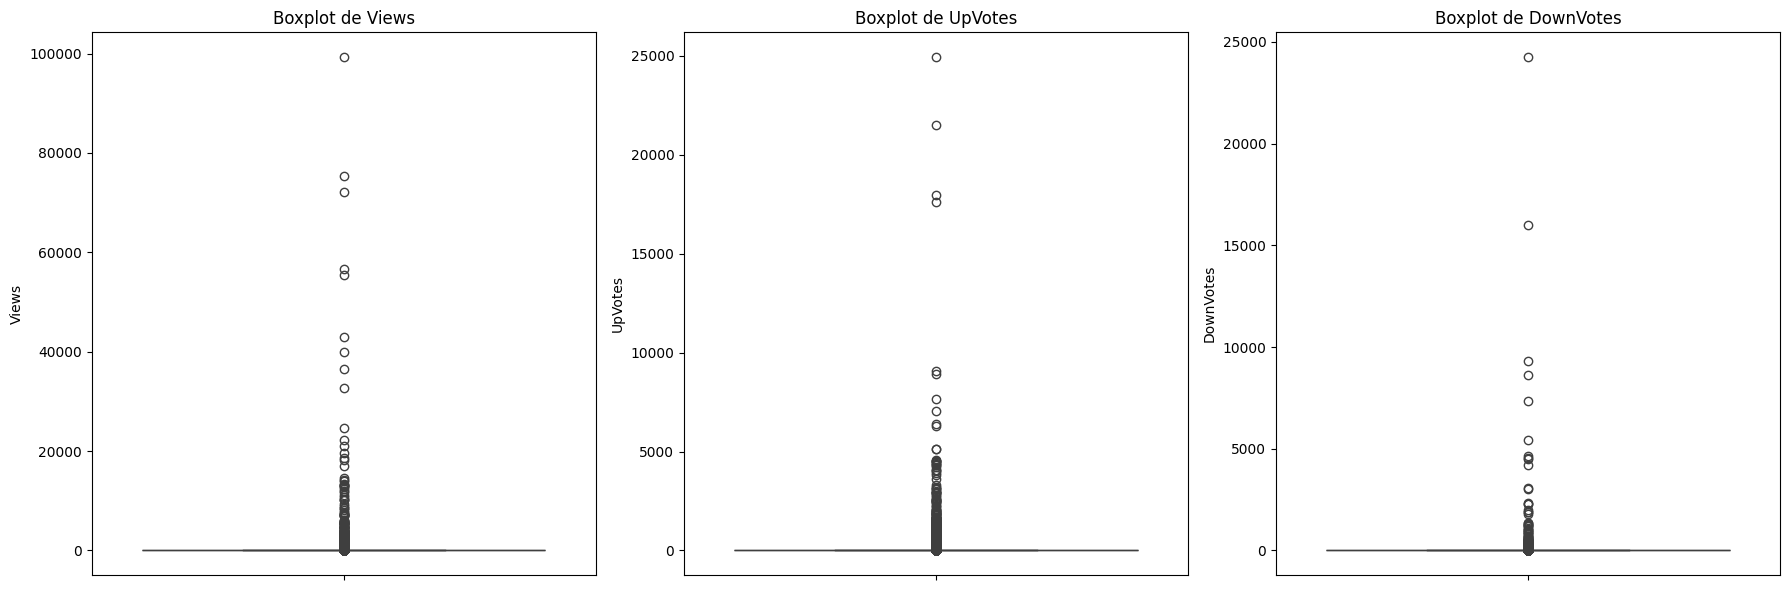

In [156]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.boxplot(y=usuariosTrain['Views'])
plt.title('Boxplot de Views')

plt.subplot(1, 3, 2)
sns.boxplot(y=usuariosTrain['UpVotes'])
plt.title('Boxplot de UpVotes')

plt.subplot(1, 3, 3)
sns.boxplot(y=usuariosTrain['DownVotes'])
plt.title('Boxplot de DownVotes')

plt.tight_layout()
plt.show()

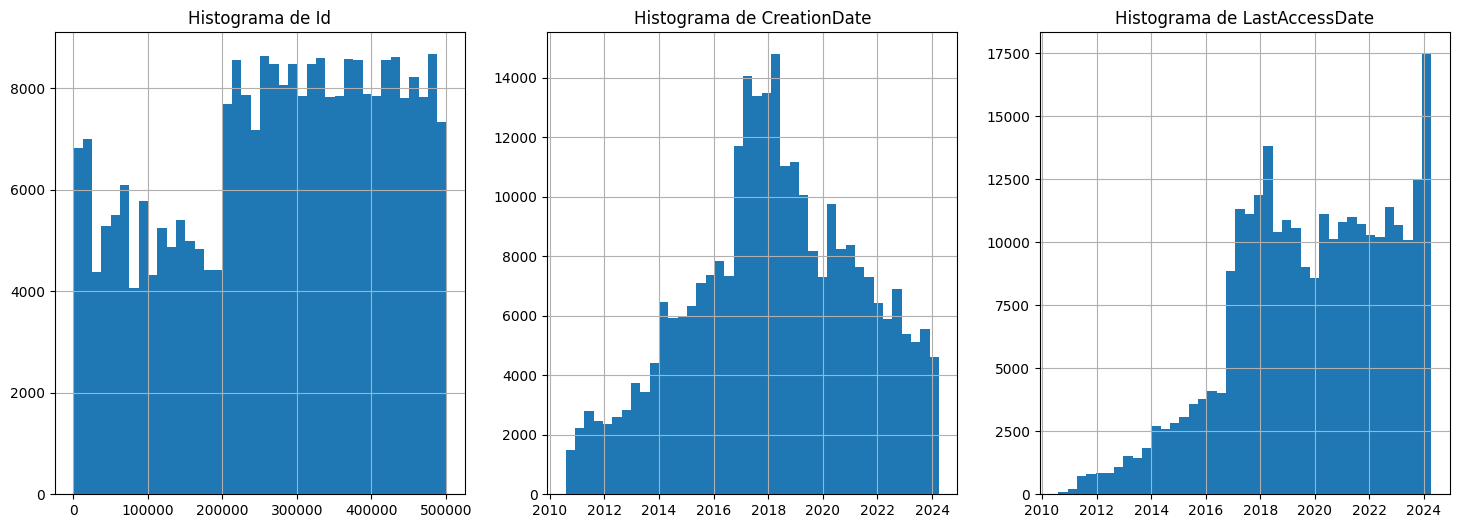

In [165]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
usuariosTrain["Id"].hist(bins=40)
plt.title("Histograma de Id")

plt.subplot(1, 3, 2)
usuariosTrain["CreationDate"].hist(bins=40)
plt.title("Histograma de CreationDate")


plt.subplot(1, 3, 3)
usuariosTrain["LastAccessDate"].hist(bins=40)
plt.title("Histograma de LastAccessDate")

plt.show()

Como podemos ver en los boxplots, no parecen ser datos erróneos, si no anómalos, de igual forma, los Id no son una distribución uniforme, en algún momento tuvo que pasar algo para que la forma en la que se guardan los Ids pasó a ser un número empezando por 200000 o algo parecido, para hacer que el corte sea justo en ese punto. Tal vez se pueda ver una relación entre las fechas de creación y el Id, pero creemos que sea relevante. En cuanto a las fechas, vemos una distribución "normal" en la creación, y la distribución que podríamos esperar de LastAccessDate, que los datos estén más cerca de fechas actuales que lejanas.

#### Corrplot

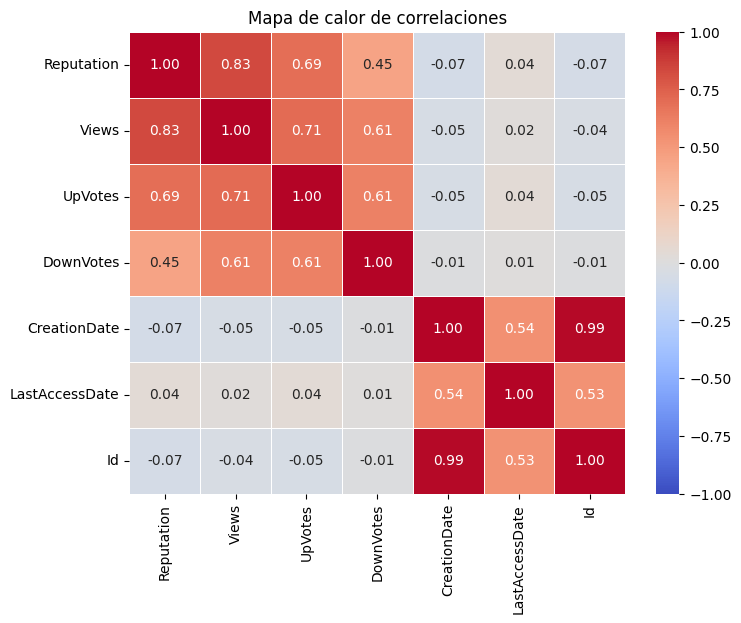

In [158]:
corr_matrix = usuariosTrain[['Reputation','Views', 'UpVotes', 'DownVotes','CreationDate','LastAccessDate','Id']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Mapa de calor de correlaciones')
plt.show()

Los resultados son los que evidentemente nos esperaríamos, una fuerte correlación entre Views y Reputation y upvotes (a más visitas sueles tener mayor reputación y vistas), y como es de esperar, a más vistas, más probable es que te den downvote. Por otra parte, vemos una muy fuerte correlación entre la fecha de creación y el Id (lo que es completamente lógico). Todas las demás relaciones son 0 o parecido, lo que indica que no hay relación.

### Variables categóricas

#### Location

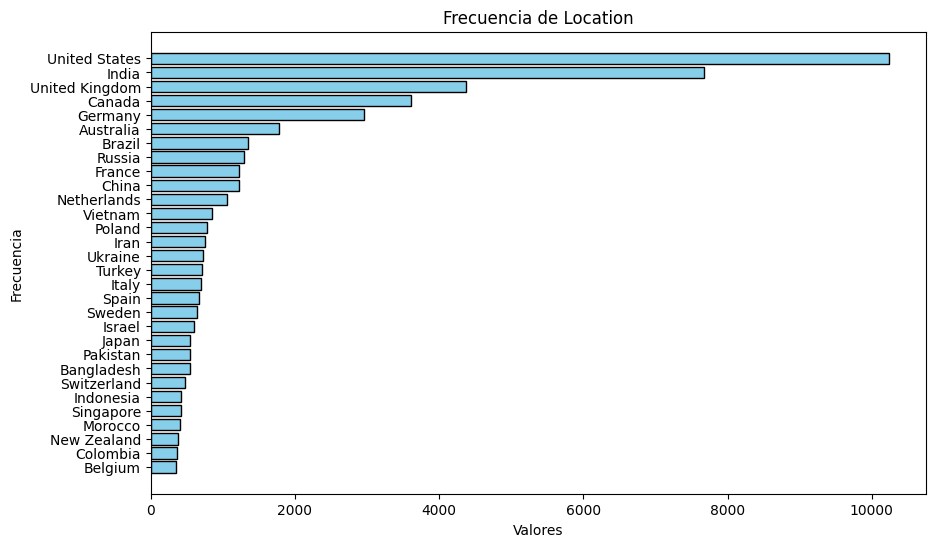

In [159]:
frecuenciasLocation = usuariosTrain['Location'].value_counts().nlargest(30).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(frecuenciasLocation.index, frecuenciasLocation.values, color='skyblue', edgecolor='black')
plt.title('Frecuencia de Location')
plt.xlabel('Valores')
plt.ylabel('Frecuencia')
plt.show()

In [160]:
#T-Studen para ver diferencia significativa entre la distribución de las Views en función de si tiene Location o no.
grupo_conLocation = usuariosTrain[usuariosTrain['HasLocation'] == True]['Views']
grupo_sinLocation = usuariosTrain[usuariosTrain['HasLocation'] == False]['Views']

_, p_value = ttest_ind(grupo_conLocation, grupo_sinLocation)
print(f"p-Value: {p_value}")

p-Value: 6.488640478842492e-29


Vemos que hay ciertos países donde cláramente está más extendido el uso de la comunidad de Stack Exannge de Inglés. En el top 5 tenemos 3 países donde el inglés es lengua principal, India, que es uno de los países con más gente si no el que más del mundo con un porcentaje significativo que habla inglés, y Alemania, uno de los países más importantes de Europa. 

Por otro lado, viéndo el test de la T-student, vemos una significancia muy muy grande entre tener el campo de location con tu país o no. Un p-valor con una escala de 10^-29, lo que implica una clara relación entre las dos variables.



#### HasUrl (WebsiteUrl)

In [161]:
grupo_conURL = usuariosTrain[usuariosTrain['HasUrl'] == 1]['Views']  # HasURL = 1 (tiene URL)
grupo_sinURL = usuariosTrain[usuariosTrain['HasUrl'] == 0]['Views']  # HasURL = 0 (no tiene URL)

# Realizar la prueba t-Student
_, p_value = ttest_ind(grupo_conURL, grupo_sinURL)

# Mostrar el resultado
print(f"p-Value: {p_value}")

p-Value: 8.26103007538622e-24


De igual forma a lo que pasaba con el campo de Location, con el campo de URL, también existe una fuerte relación entre la gente que tiene una URL y el número de visitas que tiene su perfil.